## Implementing batch sedimentation



In [1]:
#first order euler methpd to solve one-dimensional settling of hard spheres

# no-flux boundary conditions at the top and bottom of the domain

import numpy as np
import matplotlib.pyplot as plt


# def compressiblity_factor(phi):
#     Z = (1 + phi + phi**2 - phi**3) / (1 - phi)**3 # Carnahan-Starling equation of state for hard spheres
#     return Z


def compressiblity_factor(phi, kind='cs'):
    phim = np.pi/(3*np.sqrt(2))  # FCC packing fraction
    phi_freeze = 0.491
    phi_melt = 0.5431
    transition_width = 0.01  # Broader transition for smoother blending
    
    # Speedy 1998 constants
    a, b, c = 0.5921, 0.7072, 0.601
    v0 = np.pi/6
    
    # Clip phi to avoid singularities
    # phi = np.clip(phi, 0.0, phim - 1e-6)
    
    # Always compute both liquid and solid formulas
    # Liquid (Carnahan-Starling)
    Z_liq = (1 + phi + phi**2 - phi**3) / (1 - phi)**3
    
    # Solid (Speedy 1998)
    rho = phi / v0
    z = rho / np.sqrt(2)
    Z_sol = 3.0 / (1 - z) - a * (z - b) / (z - c)
    
    # Smooth blending weight across full transition zone [freeze, melt]
    # Use tanh to smoothly interpolate between formulas
    center = (phi_freeze + phi_melt) / 2
    blend = 0.5 * (1.0 + np.tanh((phi - center) / transition_width))
    
    # Blend the formulas themselves (not fixed values)
    Z = (1.0 - blend) * Z_liq + blend * Z_sol
    
    return Z

v_compressiblity_factor = np.vectorize(compressiblity_factor)

In [2]:
cs = compressiblity_factor(0.491, kind='cs')
other = compressiblity_factor(0.491, kind='other')
print(f"Compressibility factor at freezing point: {cs} (Carnahan-Starling), {other} (other)")

other-cs


Compressibility factor at freezing point: 12.221104920460977 (Carnahan-Starling), 12.221104920460977 (other)


np.float64(0.0)

In [3]:
# Check continuity at phase boundaries
phi_freeze = 0.491
phi_melt = 0.5431

# Value just below phi_melt (using the phi_freeze region formula)
z_below = compressiblity_factor(phi_melt - 0.0001, kind='cs')

# Value at phi_melt (using Speedy 1998)
z_above = compressiblity_factor(phi_melt + 0.0001, kind='cs')

print(f"Z just below melt point (phi={phi_melt - 0.0001}): {z_below}")
print(f"Z just above melt point (phi={phi_melt + 0.0001}): {z_above}")
print(f"Discontinuity: {z_above - z_below}")


Z just below melt point (phi=0.543): 11.167799378749661
Z just above melt point (phi=0.5432): 11.176922857099761
Discontinuity: 0.009123478350099745


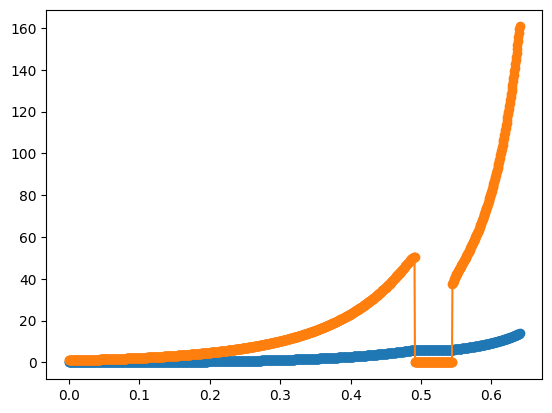

In [4]:
phis = np.linspace(0,0.64,1000)
rhos = phis / (np.pi/6)
Z = v_compressiblity_factor(phis)

def pressure(phi):
    v0 = np.pi/6
    rho = phi / v0
    P = v_compressiblity_factor(phis) * rho
    coexistence = (0.491 < phis) & (phis < 0.5431)
    P[coexistence] = P[coexistence][0] # Set pressure to NaN in the coexistence region
    return P
# plt.plot(phis,pressure(phis), '-o')

def phiZ(phi):
    # v0 = np.pi/6
    phiZ = v_compressiblity_factor(phis) * phi
    coexistence = (0.491 < phis) & (phis < 0.5431)
    phiZ[coexistence] = phiZ[coexistence][0] # Set pressure to NaN in the coexistence region
    return phiZ

plt.plot(phis,phiZ(phis), '-o')

def M(phi):
    # TODO : clean this up
    phiZ = v_compressiblity_factor(phi) * phi
    dphiZ_dphi = np.gradient(phiZ, phi)
    eps = 0.001
    coexistence = (0.491 < phi) & (phi <= 0.5431+eps)
    dphiZ_dphi[coexistence] = 0 # Set pressure to NaN in the coexistence region
    return dphiZ_dphi
plt.plot(phis,M(phis), '-o')

In [5]:


# def M(phi):




def K(phi, global_sedimentation_rate=1):
    """
    Simple empirical model for sedimentation rate as a function of packing fraction

    The units are
    - phi: packing fraction (dimensionless)
    - global_sedimentation_rate: sedimentation rate at infinite dilution (unit: sigma per unit time)
    - sedimentation_rate: sedimentation rate at packing fraction phi (unit: sigma per unit time)
    """
    return global_sedimentation_rate*(1-phi)**3/(1+2*phi+1.492*phi*(1-phi)**3)





In [6]:
from scipy.interpolate import CubicHermiteSpline
# Define the analytical branches
def get_liq(p):
    return (1 + 4*p + 4*p**2 - 4*p**3 + p**4) / (1 - p)**4

def get_sol(p):
    alpha = 1.0 / ( (np.pi/6) * np.sqrt(2) )
    a, b, c = 0.5921, 0.7072, 0.601
    z = alpha * p
    return 3.0 / (1 - z)**2 - a * (z**2 - 2*c*z + b*c) / (z - c)**2

def M(phi, coex_depth=0.99):
    phi_f = 0.491
    phi_m = 0.5431
    phi_cp = np.pi / (3 * np.sqrt(2))
    


    # Calculate values and derivatives (slopes) at boundaries
    # We use a small delta to approximate the slope for the spline
    eps = 1e-5
    m_f = get_liq(phi_f)
    slope_f = (get_liq(phi_f) - get_liq(phi_f - eps)) / eps
    
    m_m = get_sol(phi_m)
    slope_m = (get_sol(phi_m + eps) - get_sol(phi_m)) / eps

    # Target value in the middle of coexistence
    phi_mid = (phi_f + phi_m) / 2
    # m_mid represents the "depth". 1.0 = linear, 0.01 = deep dip.
    m_mid = min(m_f, m_m) * (1.0 - coex_depth) 

    # Construct a spline through (phi_f, m_f), (phi_mid, m_mid), (phi_m, m_m)
    # This ensures C1 continuity at the boundaries
    phis = [phi_f, phi_mid, phi_m]
    vals = [m_f, m_mid, m_m]
    slopes = [slope_f, 0, slope_m] # Force slope=0 at the bottom of the U
    
    # Use CubicHermiteSpline for total control over boundary slopes
    spline = CubicHermiteSpline(phis, vals, slopes)

    # Apply piecewise
    phi = np.asarray(phi)
    res = np.zeros_like(phi)
    
    mask_l = phi < phi_f
    mask_c = (phi >= phi_f) & (phi <= phi_m)
    mask_s = phi > phi_m
    
    res[mask_l] = get_liq(phi[mask_l])
    res[mask_c] = spline(phi[mask_c])
    res[mask_s] = get_sol(phi[mask_s])
    
    return res

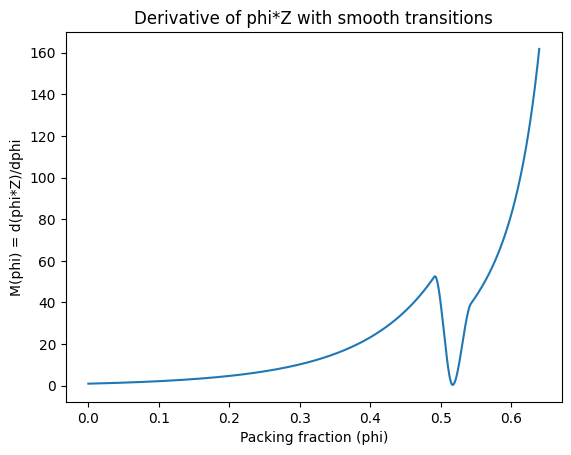

In [7]:
# plot M(phi) to check for any discontinuities
phis = np.linspace(0, 0.64, 1000)
plt.plot(phis, M(phis), '-')
plt.xlabel('Packing fraction (phi)')
plt.ylabel('M(phi) = d(phi*Z)/dphi')
plt.title('Derivative of phi*Z with smooth transitions')
# plt.grid()
plt.show()

In [8]:
# Check the boundary values of M
phi_freeze = 0.491
phi_melt = 0.5431

M_freeze_val = M(phi_freeze)
M_melt_val = M(phi_melt)

print(f"M at φ_freeze = {phi_freeze}: {M_freeze_val}")
print(f"M at φ_melt = {phi_melt}: {M_melt_val}")
print(f"Range in coexistence: [{min(M_freeze_val, M_melt_val)}, {max(M_freeze_val, M_melt_val)}]")


M at φ_freeze = 0.491: 52.336200993752165
M at φ_melt = 0.5431: 39.47556320857946
Range in coexistence: [39.47556320857946, 52.336200993752165]


In [9]:
from scipy.integrate import solve_ivp

# Switch: 'upwind' (1st order, monotone) or 'minmod' (2nd order TVD, less diffusive)
advection_scheme = 'upwind'

# Tunable parameter: depth of U-shape in coexistence [0, 1]
# 0 = flat M (no suppression), 1 = full U-shape (M → 0 at center)
# Start shallow to avoid stiffness; increase gradually if needed
coex_depth = 0.07

def dphi_dt(t, phi):
    # phi = np.clip(phi, 0, np.pi/(3*np.sqrt(2)))  # Clip to FCC packing maximum
    phi = phi.reshape(x.shape)
    dx_val = x[1] - x[0]

    # --- Sedimentation flux ---
    f_sed = U0 * K(phi) * phi          # cell-centre flux values
    flux_sed = np.empty(npoints + 1)
    flux_sed[0]   = 0.0                # no-flux left wall
    flux_sed[-1]  = 0.0                # no-flux right wall

    if advection_scheme == 'upwind':
        # First-order upwind: use left cell (flow toward +x)
        flux_sed[1:-1] = f_sed[:-1]

    elif advection_scheme == 'minmod':
        # Minmod TVD: 2nd order in smooth regions, 1st order near sharp fronts
        dphi = np.diff(phi)            # length npoints-1
        # r[i] = upwind gradient / local gradient at face i+1  (i=1..npoints-2)
        with np.errstate(divide='ignore', invalid='ignore'):
            r = np.where(np.abs(dphi[1:-1]) > 1e-12,
                         dphi[:-2] / dphi[1:-1], 0.0)  # length npoints-3
        lim = np.clip(r, 0.0, 1.0)                     # minmod limiter: ψ(r)=clip(r,0,1)
        # Interior faces 1..npoints-2 (length npoints-2, skip face 1 and face npoints-1)
        flux_sed[1]         = f_sed[0]                 # first interior face: pure upwind
        flux_sed[-2]        = f_sed[-2]                # last interior face:  pure upwind
        flux_sed[2:-2] = f_sed[1:-2] + lim * (f_sed[2:-1] - f_sed[1:-2])

    # --- Diffusion flux: centred ---
    phi_face = np.empty(npoints + 1)
    phi_face[1:-1] = 0.5 * (phi[:-1] + phi[1:])
    phi_face[0]    = phi[0]
    phi_face[-1]   = phi[-1]

    dphidx_face = np.empty(npoints + 1)
    dphidx_face[1:-1] = (phi[1:] - phi[:-1]) / dx_val
    dphidx_face[0]    = 0.0
    dphidx_face[-1]   = 0.0

    flux_diff = D0 * K(phi_face) * M(phi_face, coex_depth=coex_depth) * dphidx_face
    flux_diff[0]  = 0.0
    flux_diff[-1] = 0.0

    f = flux_diff - flux_sed
    div = (f[1:] - f[:-1]) / dx_val

    return div.flatten()


phi0 = 0.51  # bulk packing fraction
sigma = 1.0  # particle diameter
L = 20000 * sigma
npoints = 1000
x = np.linspace(0, L, npoints)
dx_val = x[1] - x[0]

# Initial condition: zero at left wall, blending to phi0 over ~50 space units
blend_center = 30 * dx_val
blend_width  = 3*dx_val
phi = phi0 * 0.5 * (1 + np.tanh((x - blend_center) / blend_width))
brownian_time = 1
tmax = 100_000 * brownian_time
dt = 0.05
U0 = 1.0
D0 = 1.0
phi0_flat = phi.flatten()
t_span = (0, tmax)
method = 'Radau'
from scipy.sparse import diags

# minmod stencil touches 4 cells per face → pentadiagonal Jacobian
if advection_scheme == 'minmod':
    jac_sparsity = diags([1, 1, 1, 1, 1], [-2, -1, 0, 1, 2], shape=(npoints, npoints), format='csc')
else:
    jac_sparsity = diags([1, 1, 1], [-1, 0, 1], shape=(npoints, npoints), format='csc')

solution = solve_ivp(dphi_dt, t_span, phi0_flat, method=method,
                     t_eval=np.linspace(0, tmax, 10),
                     jac_sparsity=jac_sparsity, rtol=1e-3, atol=1e-5)


Method:       Radau
Scheme:       upwind
RHS evals:    14062
Steps taken:  10
Success:      True
Message:      The solver successfully reached the end of the integration interval.
time=11111.11, average packing fraction: 0.6997
time=22222.22, average packing fraction: 0.7104
time=33333.33, average packing fraction: 0.7143
time=44444.44, average packing fraction: 0.7168
time=55555.56, average packing fraction: 0.7179
time=66666.67, average packing fraction: 0.7191
time=77777.78, average packing fraction: 0.7199
time=88888.89, average packing fraction: 0.7205
time=100000.00, average packing fraction: 0.7210


/var/folders/k2/zvg_gcvj6dz5q4_t5p1n04240000gp/T/ipykernel_23919/481798615.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  avg_phi_solid = np.trapz(profile[valid], sol)/domain_size


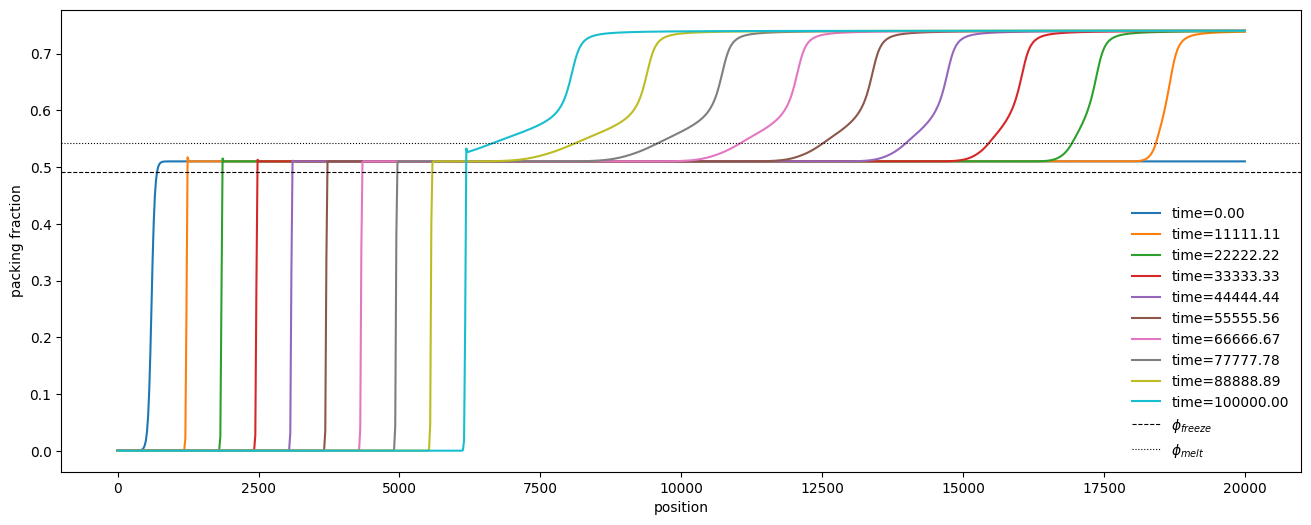

In [10]:

print(f"Method:       {method}")
print(f"Scheme:       {advection_scheme}")
print(f"RHS evals:    {solution.nfev}")
print(f"Steps taken:  {solution.t.size}")
print(f"Success:      {solution.success}")
print(f"Message:      {solution.message}")
plt.figure(figsize=(16, 6))

ts = []
phis_solid = []
for i in range(solution.y.shape[1]):


    plt.plot(x, solution.y[:, i].reshape(x.shape), label=f'time={solution.t[i]:.2f}')
    if i>0:
        profile=solution.y[:, i].reshape(x.shape)
        valid = (profile > 0.5431)
        xm = x[profile<=0.5431][-1] # position of the solid-liquid interface
        valid = valid *(x>xm)
        # size of the solid region
        sol = x[valid]
        # print(xm)
        domain_size =x[-1]-xm
        # print(xm)
        # average packing fraction in the solid region

        avg_phi_solid = np.trapz(profile[valid], sol)/domain_size
        ts.append(solution.t[i])
        phis_solid.append(avg_phi_solid)
        # avg_phi_solid = np.mean(profile[valid])
        print(f"time={solution.t[i]:.2f}, average packing fraction: {avg_phi_solid:.4f}")
plt.xlabel('position')
plt.ylabel('packing fraction')
plt.axhline(0.491,  color='k', ls='--', lw=0.8, label='$\\phi_{freeze}$')
plt.axhline(0.5431, color='k', ls=':', lw=0.8, label='$\\phi_{melt}$')
plt.legend(frameon=False)
plt.show()


[3.75082551e-02 6.82957832e-01 1.82020653e+04]


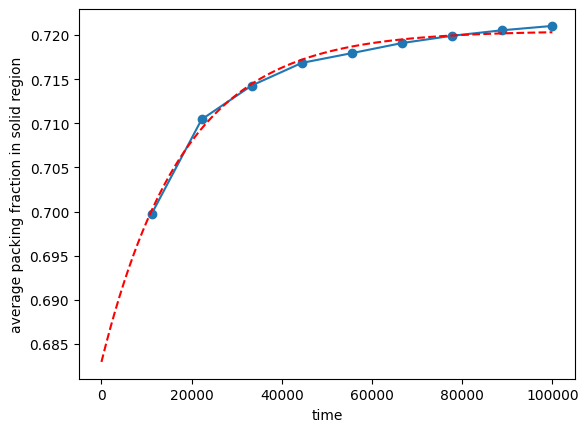

In [11]:
plt.plot(ts, phis_solid, '-o')
# fit saturation curve
mode = lambda t, A,B, tau: A * (1 - np.exp(-t/tau))+B
from scipy.optimize import curve_fit
popt, pcov = curve_fit(mode, ts, phis_solid,p0=[0.64, 0.2, 10000])
# A_fit, tau_fit = popt   
t_fit = np.linspace(10, max(ts), 100)
plt.plot(t_fit, mode(t_fit, *popt), 'r--', )
# 
# label=f'fit: A={A_fit:.3f}, tau={tau_fit:.1f}')  
print(popt)
plt.xlabel('time')
plt.ylabel('average packing fraction in solid region')
plt.show()

In [12]:

# from math import pi
# from pde import PDE, CartesianGrid, MemoryStorage, ScalarField, plot_kymograph


# # initialize the equation and the space
# phim= 0.58
# eq = PDE({"phi": f"-gradient ((1-phi)**6.55 *(phi-1/{0.1}*1.85*{phim}/({phim}-phi)**2)*gradient(phi))"}
          
          
          
          
#         #   "gradient((1-phi)**3/(1+2*phi+1.492*phi*(1-phi)**3)*((1 + phi + phi**2 - phi**3) / (1 - phi)**3 +phi* (1 + 4*phi + 4*phi**2 - 4*phi**3 + phi**4) / (1 - phi)**4 *gradient(phi)))"}
      
#         #
#         # -gradient(phi*( (1-phi)**3/(1+2*phi+1.492*phi*(1-phi)**3)))+
        
#         # gradient((1-phi)**3/(1+2*phi+1.492*phi*(1-phi)**3)*((1 + phi + phi**2 - phi**3) / (1 - phi)**3 +phi* (1 + 4*phi + 4*phi**2 - 4*phi**3 + phi**4) / (1 - phi)**4 *gradient(phi)))
#         #  /
#         #  "  },
# # bc={"phi": bc_zero_flux}
# )


# grid = CartesianGrid([[0, 100]], [1000], periodic=True)
# state = ScalarField.from_expression(grid, "0.5*x/x")

# # solve the equation and store the trajectory
# # storage = MemoryStorage()
# eq.solve(state, t_range=3, solver="scipy",) #tracker=storage.tracker(0.1))

# # plot the trajectory as a space-time plot
# # plot_kymograph(storage)

In [13]:
# from math import pi

# from pde import PDE, CartesianGrid, MemoryStorage, ScalarField, plot_kymograph

# # initialize the equation and the space
# eq = PDE({"phi": "laplace(phi)"})
# grid = CartesianGrid([[0, 2 * pi]], [32], periodic=True)
# state = ScalarField.from_expression(grid, "0.5*x/x")

# # solve the equation and store the trajectory
# storage = MemoryStorage()
# eq.solve(state, t_range=3, solver="scipy", tracker=storage.tracker(0.1))

# # plot the trajectory as a space-time plot
# plot_kymograph(storage)